In [1]:
import rustworkx as rx
import matplotlib.pyplot as plt
import numpy as np
from tn4qa.quantum_algorithms.hamiltonian_simulation.qdrift import QDriftSimulation
from nbed.ham_builder import HamiltonianBuilder
import pyscf
import qiskit.qasm2
import json

import ferrmion as fr
from ferrmion.optimize import bonsai_algorithm

In [2]:
garnet_edges = [
    (1, 0),
    (1, 4),
    (3, 0),
    (3, 2),
    (3, 4),
    (3, 8),
    (5, 4),
    (5, 6),
    (5, 10),
    (7, 2),
    (7, 8),
    (7, 12),
    (9, 4),
    (9, 8),
    (9, 10),
    (9, 14),
    (11, 6),
    (11, 10),
    (11, 16),
    (13, 8),
    (13, 12),
    (13, 14),
    (13, 17),
    (15, 10),
    (15, 14),
    (15, 16),
    (15, 19),
    (18, 14),
    (18, 17),
    (18, 19)
]

In [3]:
def make_ham_real(hamiltonian: dict[str, complex]) -> dict[str, float]:
    real_ham = {}
    for item in hamiltonian:
        real_ham[item] = np.real(hamiltonian[item])
    return real_ham

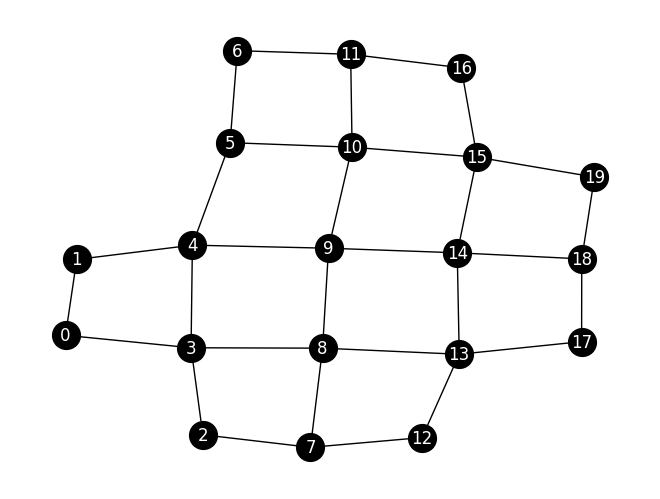

In [4]:
#rustworkx graph from edges (the actual input for bonsai)

garnet_graph_rx = rx.PyGraph()
num_qubits = max(max(pair) for pair in garnet_edges) + 1
garnet_graph_rx.add_nodes_from(range(num_qubits))
garnet_graph_rx.add_edges_from_no_data(garnet_edges)

rx.visualization.mpl_draw(
    graph = garnet_graph_rx, 
    with_labels = True,
    node_color = 'black',
    node_size = 400,
    font_color = 'white',
    pos = rx.spring_layout(garnet_graph_rx, seed=5)
)

In [5]:
mol_obj = pyscf.M(
    atom = 'mols/H2O.xyz',
    basis = 'sto-3g'
)

n_qubits = mol_obj.nao * 2

print('qubits =', n_qubits)

qubits = 14


In [6]:
rhf_obj = pyscf.scf.RHF(mol_obj).run()

converged SCF energy = -74.9659011922597


In [7]:
e_nuc, one_e_coeffs, two_e_coeffs = HamiltonianBuilder(
    scf_method=rhf_obj,
    constant_e_shift=mol_obj.energy_nuc()
).build()

In [8]:
n_modes = one_e_coeffs.shape[0]
n_modes

14

In [9]:
bonsai_garnet_truncated = bonsai_algorithm(
    graph = garnet_graph_rx,
    homogenous = False,
    max_nodes = n_modes
)

In [10]:
bonsai_garnet_truncated.n_qubits

20

In [11]:
def get_hams(name, tree, ones, twos, enuc):
    n_modes = ones.shape[0]

    if name in ["Jordan-Wigner", "Parity", "Bravyi-Kitaev", "JKMN", "JW", "BK", "PE"]:
        ham = fr.core.encode_standard(
            encoding=name,
            n_modes=n_modes,
            n_qubits=n_modes, # for standard we assume n_qubits = n_modes
            signatures=["+-","++--"],
            coeffs=[ones, twos],
            constant_energy=enuc,
        )
        
        ham = make_ham_real(ham)
        
        ipow,sym = fr.core.topphatt_standard(
            encoding=name,
            n_modes=n_modes,
            n_qubits=n_modes,
            signatures=["+-","++--"],
            coeffs=[ones, twos]
        )
    
    else:
        fermion_hamiltonian = fr.molecular_hamiltonian(
            one_e_coeffs = ones, 
            two_e_coeffs = twos, 
            constant_energy = e_nuc
        )
        
        ham = tree.encode(fermion_hamiltonian)
        ham = make_ham_real(ham)

        ipow,sym = fr.core.topphatt(
            flatpack=tree.flatpack(),
            n_qubits=tree.n_qubits,
            signatures=["+-","++--"], 
            coeffs=[ones, twos]
        )

    # build topphatt ham from ipowers and symplectics
    ham_topphatt = fr.core.encode(
        ipowers=ipow,
        symplectics=sym,
        signatures=["+-","++--"],
        coeffs=[ones, twos],
        constant_energy=enuc
    )
    ham_topphatt = make_ham_real(ham_topphatt)
    return (ham, ham_topphatt)

In [12]:
jw_hams = get_hams(
    name="Jordan-Wigner",
    tree=None,
    ones=one_e_coeffs,
    twos=two_e_coeffs,
    enuc=e_nuc
)

bk_hams = get_hams(
    name="Bravyi-Kitaev",
    tree=None,
    ones=one_e_coeffs,
    twos=two_e_coeffs,
    enuc=e_nuc
)

parity_hams = get_hams(
    name="Parity",
    tree=None,
    ones=one_e_coeffs,
    twos=two_e_coeffs,
    enuc=e_nuc
)

jkmn_hams = get_hams(
    name="JKMN",
    tree=None,
    ones=one_e_coeffs,
    twos=two_e_coeffs,
    enuc=e_nuc
)

bonsai_hams = get_hams(
    name=None,
    tree=bonsai_garnet_truncated,
    ones=one_e_coeffs,
    twos=two_e_coeffs,
    enuc=e_nuc
)

In [13]:
def run_qdrift(hams, duration):
    qdrift = QDriftSimulation(
        hamiltonian = hams[0],
        duration = duration
    )
    naive_depth = qdrift.circuit.depth()

    qdrift = QDriftSimulation(
        hamiltonian = hams[1],
        duration = duration
    )
    tophatt_depth = qdrift.circuit.depth()

    return (naive_depth, tophatt_depth)

In [14]:
results = {
    "bonsai" : {
        "hams" : bonsai_hams,  
        "naive" : [], 
        "topphatt" : [], 
        "naive_mean_depth" : 0,
        "naive_mean_qasm" : "",
        "topphatt_mean_depth" : 0,
        "topphatt_mean_qasm" : "",
    },
    "JW" : {
        "hams" : jw_hams,  
        "naive" : [], 
        "topphatt" : [], 
        "naive_mean_depth" : 0,
        "naive_mean_qasm" : "",
        "topphatt_mean_depth" : 0,
        "topphatt_mean_qasm" : "",
    },
    "BK" : {
        "hams" : bk_hams,  
        "naive" : [], 
        "topphatt" : [], 
        "naive_mean_depth" : 0,
        "naive_mean_qasm" : "",
        "topphatt_mean_depth" : 0,
        "topphatt_mean_qasm" : "",
    },
    "parity" : {
        "hams" : parity_hams,  
        "naive" : [], 
        "topphatt" : [], 
        "naive_mean_depth" : 0,
        "naive_mean_qasm" : "",
        "topphatt_mean_depth" : 0,
        "topphatt_mean_qasm" : "",
    },
    "JKMN" : {
        "hams" : jkmn_hams,  
        "naive" : [], 
        "topphatt" : [], 
        "naive_mean_depth" : 0,
        "naive_mean_qasm" : "",
        "topphatt_mean_depth" : 0,
        "topphatt_mean_qasm" : "",
    },
}

In [15]:
dur = 0.001
repeats = 1000

for _ in range(repeats):
    for encoding, data in results.items():
        naive_depth, tophatt_depth = run_qdrift(data["hams"], dur)
        data["naive"].append(naive_depth)
        data["topphatt"].append(tophatt_depth)

In [16]:
with open("untranspiled_results.json", 'w') as f:
    json.dump(results, f)

In [17]:
with open("untranspiled_results.json", 'r') as f:
    results = json.load(f)

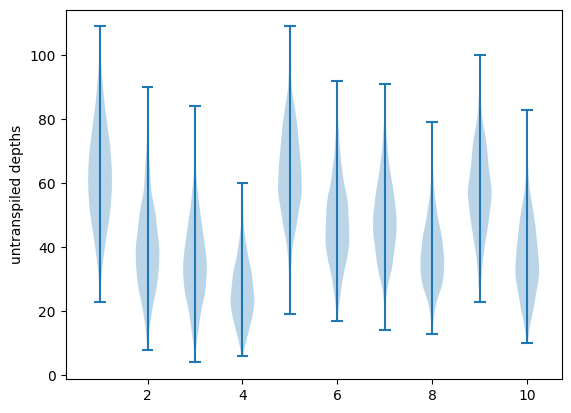

In [18]:
plt.violinplot([
    results["bonsai"]["naive"],
    results["bonsai"]["topphatt"],
    results["JW"]["naive"],
    results["JW"]["topphatt"],
    results["BK"]["naive"],
    results["BK"]["topphatt"],
    results["parity"]["naive"],
    results["parity"]["topphatt"],
    results["JKMN"]["naive"],
    results["JKMN"]["topphatt"],
])

plt.ylabel('untranspiled depths')

plt.show()

In [19]:
for encoding, data in results.items():
    print(encoding)

bonsai
JW
BK
parity
JKMN


In [20]:
order = ["JW", "parity", "BK", "JKMN", "bonsai"]
names = ["Jordan-Wigner", "Parity", "Bravyi-Kitaev", "JKMN", "Bonsai"]


JW
naive 1000
35.2 12.4
TOPP-HATT 1000
26.3 9.5
reduction
25.2 37.8

parity
naive 1000
49.0 12.6
TOPP-HATT 1000
37.9 10.2
reduction
22.7 28.7

BK
naive 1000
63.3 14.0
TOPP-HATT 1000
47.5 12.6
reduction
25.0 26.0

JKMN
naive 1000
57.8 13.0
TOPP-HATT 1000
36.9 12.1
reduction
36.1 25.5

bonsai
naive 1000
62.7 15.2
TOPP-HATT 1000
39.7 13.2
reduction
36.7 26.1


29.1, 6.0


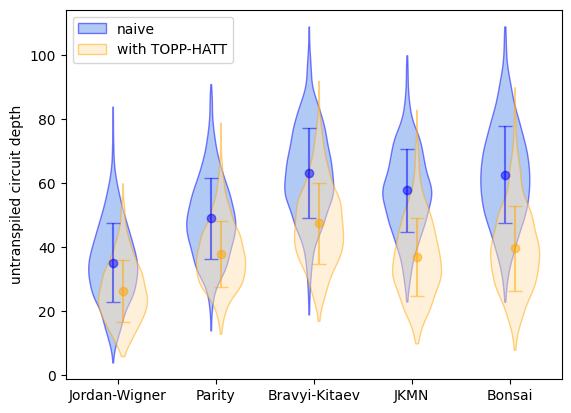

In [21]:
spacing = 0.05

naive_data   = [results[name]["naive"] for name in order]
tophatt_data = [results[name]["topphatt"]    for name in order]

positions_naive   = [i + 1 - spacing for i in range(len(order))]
positions_tophatt = [i + 1 + spacing for i in range(len(order))]

plt.tight_layout()

naive_violin = plt.violinplot(
    dataset=naive_data,
    positions=positions_naive,
)
tophatt_violin = plt.violinplot(
    dataset=tophatt_data,
    positions=positions_tophatt,
)

alpha = 0.5
naive_edge = 'blue'
naive_fill = 'cornflowerblue'
tophatt_edge = 'orange'
tophatt_fill = 'moccasin'

for i, body in enumerate(naive_violin['bodies']):
    body.set_facecolor(naive_fill)
    body.set_edgecolor(naive_edge)
    body.set_alpha(alpha)

naive_violin['bodies'][0].set_label("naive")

for i, body in enumerate(tophatt_violin['bodies']):
    body.set_facecolor(tophatt_fill)
    body.set_edgecolor(tophatt_edge)
    body.set_alpha(alpha)

tophatt_violin['bodies'][0].set_label("with TOPP-HATT")


for key in ["cbars", "cmaxes", "cmins"]:
    naive_violin[key].set_color("none")
    tophatt_violin[key].set_color("none")

reductions = []

for i, encoding in enumerate(order):
    x_naive = positions_naive[i]
    x_topphatt = positions_tophatt[i]

    y_naive = np.mean(results[encoding]["naive"])
    e_naive = np.std(results[encoding]["naive"])

    y_topphatt = np.mean(results[encoding]["topphatt"])
    e_topphatt = np.std(results[encoding]["topphatt"])

    plt.errorbar(x=x_naive, y=y_naive,
                 yerr=e_naive, fmt='o', color=naive_edge,
                 capsize=5, alpha=alpha)

    plt.errorbar(x=x_topphatt, y=y_topphatt,
                 yerr=e_topphatt, fmt='o', color=tophatt_edge,
                 capsize=5, alpha=alpha)
    
    reductions.append(100*(1 - y_topphatt/y_naive))
    
    print(encoding)
    print('naive', len(results[encoding]["naive"]))
    print(f'{y_naive:.1f}', f'{e_naive:.1f}')
    print('TOPP-HATT', len(results[encoding]["topphatt"]))
    print(f'{y_topphatt:.1f}', f'{e_topphatt:.1f}')
    print('reduction')
    print(f'{100*(1 - y_topphatt/y_naive):.1f}', f'{100*np.sqrt((y_topphatt**2 * e_naive**2)/(y_naive**4) + (e_topphatt**2)/(y_naive**2)):.1f}')
    print()

print()
print(f'{np.mean(reductions):.1f}, {np.std(reductions):.1f}')

plt.legend(loc="upper left")
plt.xticks([i + 1 for i in range(len(order))], names)
plt.ylabel("untranspiled circuit depth")

plt.savefig("untranspiled_qdrift.pdf")

plt.show()

In [22]:
for encoding in results:
    print(encoding)

bonsai
JW
BK
parity
JKMN


In [23]:
for encoding in results.keys():
    data = results[encoding]
    hams = data["hams"]

    for variant, ham in zip(["naive", "topphatt"], hams):
        
        target_depth = int(np.mean(data[variant]))

        while True:
            qdrift = QDriftSimulation(hamiltonian=ham, duration=dur)

            if qdrift.circuit.depth() == target_depth:
                results[encoding][f"{variant}_mean_depth"] = target_depth
                results[encoding][f"{variant}_mean_qasm"] = qiskit.qasm2.dumps(qdrift.circuit)
                print(f"done {encoding} {variant} {target_depth}")
                break

NameError: name 'dur' is not defined

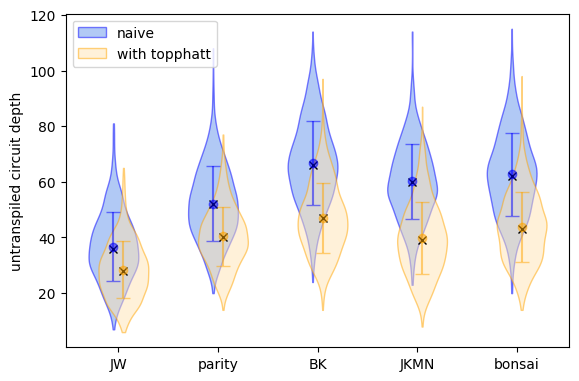

In [24]:
spacing = 0.05

naive_data   = [results[name]["naive"] for name in order]
tophatt_data = [results[name]["topphatt"]    for name in order]

positions_naive   = [i + 1 - spacing for i in range(len(order))]
positions_tophatt = [i + 1 + spacing for i in range(len(order))]

plt.figure(figsize=(468/72, (468*(2/3))/72))
plt.tight_layout()

naive_violin = plt.violinplot(
    dataset=naive_data,
    positions=positions_naive,
)
tophatt_violin = plt.violinplot(
    dataset=tophatt_data,
    positions=positions_tophatt,
)

alpha = 0.5
naive_edge = 'blue'
naive_fill = 'cornflowerblue'
tophatt_edge = 'orange'
tophatt_fill = 'moccasin'

for i, body in enumerate(naive_violin['bodies']):
    body.set_facecolor(naive_fill)
    body.set_edgecolor(naive_edge)
    body.set_alpha(alpha)

naive_violin['bodies'][0].set_label("naive")

for i, body in enumerate(tophatt_violin['bodies']):
    body.set_facecolor(tophatt_fill)
    body.set_edgecolor(tophatt_edge)
    body.set_alpha(alpha)

tophatt_violin['bodies'][0].set_label("with topphatt")


for key in ["cbars", "cmaxes", "cmins"]:
    naive_violin[key].set_color("none")
    tophatt_violin[key].set_color("none")

for i, name in enumerate(order):
    x_naive = positions_naive[i]
    x_topphatt = positions_tophatt[i]

    y_naive = np.mean(results[name]["naive"])
    e_naive = np.std(results[name]["naive"])

    y_topphatt = np.mean(results[name]["topphatt"])
    e_topphatt = np.std(results[name]["topphatt"])

    depth_naive = results[name]["naive_mean_depth"]
    depth_topphatt = results[name]["topphatt_mean_depth"]

    plt.errorbar(x=x_naive, y=y_naive,
                 yerr=e_naive, fmt='o', color=naive_edge,
                 capsize=5, alpha=alpha)

    plt.errorbar(x=x_topphatt, y=y_topphatt,
                 yerr=e_topphatt, fmt='o', color=tophatt_edge,
                 capsize=5, alpha=alpha)
    
    plt.plot(x_naive, depth_naive, 'x', color='black')
    plt.plot(x_topphatt, depth_topphatt, 'x', color='black')

plt.legend(loc="upper left")
plt.xticks([i + 1 for i in range(len(order))], order)
plt.ylabel("untranspiled circuit depth")

plt.show()

In [26]:
with open("untranspiled_results.json", 'w') as f:
    json.dump(results, f, indent=4)

# water with different qDRIFT durations

In [25]:
import pyscf
from nbed.ham_builder import HamiltonianBuilder
from ferrmion import TernaryTree
import numpy as np
from ferrmion.hamiltonians import molecular_hamiltonian
from ferrmion.utils import fermionic_to_sparse_majorana
from ferrmion.optimize.topphatt import topphatt
from tn4qa.quantum_algorithms.hamiltonian_simulation.qdrift import QDriftSimulation
import matplotlib.pyplot as plt
import json

In [26]:
def pauli_weights(pauli_hamiltonian: dict[str, float]) -> list[float]:
    unscaled_terms = []
    scaled_terms = []
    for k, v in pauli_hamiltonian.items():
        assert v != 0
        pw = (len(k) - k.count("I")) 
        unscaled_terms.append(pw)
        scaled_terms.append(pw* np.abs(v))

    return (unscaled_terms, scaled_terms, len(pauli_hamiltonian))

In [27]:
def make_ham_real(hamiltonian: dict[str, complex]) -> dict[str, float]:
    real_ham = {}
    for item in hamiltonian:
        real_ham[item] = np.real(hamiltonian[item])
    return real_ham

In [28]:
def compare_qdrift_circuit(
        one_e_coeffs, 
        two_e_coeffs, 
        constant_energy,
        duration
    ):
    
    tt = TernaryTree.from_hamiltonian_coefficients((one_e_coeffs, two_e_coeffs))
    jw = tt.JW()
    jw.enumeration_scheme = jw.default_enumeration_scheme()

    JW_ham = molecular_hamiltonian(
        encoding=jw, 
        one_e_coeffs=one_e_coeffs, 
        two_e_coeffs=two_e_coeffs, 
        constant_energy=constant_energy
    )

    JW_ham = make_ham_real(JW_ham)

    majorana_ham = fermionic_to_sparse_majorana(
        [(one_e_coeffs, "+-"), (two_e_coeffs, "++--")]
    )

    TH_tree = topphatt(
        majorana_ham=majorana_ham,
        tree=jw
    )

    TH_ham = molecular_hamiltonian(
        encoding=TH_tree,
        one_e_coeffs=one_e_coeffs,
        two_e_coeffs=two_e_coeffs,
        constant_energy=constant_energy,
    )

    TH_ham = make_ham_real(TH_ham)

    QD_JW = QDriftSimulation(
        hamiltonian=JW_ham,
        duration=duration
    )

    QD_TH = QDriftSimulation(
        hamiltonian=TH_ham,
        duration=duration
    )

    return QD_JW.circuit.depth(), QD_TH.circuit.depth()

In [29]:
mol_obj = pyscf.M(
    atom = 'mols/H2O.xyz',
    basis = 'sto-3g'
)

rhf_obj = pyscf.scf.RHF(mol_obj).run()

e_nuc, one_e_coeffs, two_e_coeffs = HamiltonianBuilder(
    scf_method=rhf_obj,
    constant_e_shift=mol_obj.energy_nuc()
).build()

converged SCF energy = -74.9659011922597


In [30]:
depths = np.arange(0.001, 0.011, 0.0005)
depths

array([0.001 , 0.0015, 0.002 , 0.0025, 0.003 , 0.0035, 0.004 , 0.0045,
       0.005 , 0.0055, 0.006 , 0.0065, 0.007 , 0.0075, 0.008 , 0.0085,
       0.009 , 0.0095, 0.01  , 0.0105])

In [31]:
results = {str(i) : {"JW" : [], "TH" : []} for i, _ in enumerate(depths)}

In [32]:
results

{'0': {'JW': [], 'TH': []},
 '1': {'JW': [], 'TH': []},
 '2': {'JW': [], 'TH': []},
 '3': {'JW': [], 'TH': []},
 '4': {'JW': [], 'TH': []},
 '5': {'JW': [], 'TH': []},
 '6': {'JW': [], 'TH': []},
 '7': {'JW': [], 'TH': []},
 '8': {'JW': [], 'TH': []},
 '9': {'JW': [], 'TH': []},
 '10': {'JW': [], 'TH': []},
 '11': {'JW': [], 'TH': []},
 '12': {'JW': [], 'TH': []},
 '13': {'JW': [], 'TH': []},
 '14': {'JW': [], 'TH': []},
 '15': {'JW': [], 'TH': []},
 '16': {'JW': [], 'TH': []},
 '17': {'JW': [], 'TH': []},
 '18': {'JW': [], 'TH': []},
 '19': {'JW': [], 'TH': []}}

In [43]:
repeats = 100

for i in range(repeats):
    for j, depth in enumerate(depths):
        JW_d, TH_d = compare_qdrift_circuit(
            one_e_coeffs, 
            two_e_coeffs, 
            e_nuc,
            duration=depth
        )
            
        results[str(j)]["JW"].append(JW_d)
        results[str(j)]["TH"].append(TH_d)

    print('done repeat', i + 1, 'of', repeats, end='\r')

In [44]:
results["depths"] = depths.tolist()

In [45]:
with open("qdrift_depths_scan.json", 'w') as f:
    json.dump(results, f, indent=4)

In [33]:
with open("qdrift_depths_scan.json", 'r') as f:
    results = json.load(f)

In [34]:
depths = results["depths"]

In [35]:
JW_mean_depths = []
JW_std_depths = []
TH_mean_depths = []
TH_std_depths = []

for i, _ in enumerate(depths):
    JW_mean_depths.append(np.mean(results[str(i)]["JW"]))
    JW_std_depths.append(np.std(results[str(i)]["JW"]))
    TH_mean_depths.append(np.mean(results[str(i)]["TH"]))
    TH_std_depths.append(np.std(results[str(i)]["TH"]))

In [36]:
reductions = []

for i, depth in enumerate(JW_mean_depths):
    reductions.append(100*(1 - TH_mean_depths[i]/depth))
    print(f'{depths[i]:.4f}', '&', f'{depth:.1f}', '&', f'{TH_mean_depths[i]:.1f}', '&',  f'{100*(1 - TH_mean_depths[i]/depth):.1f}', ''.join(['\ ' '\ ']))

print()
print(f'{np.mean(reductions):.1f}, {np.std(reductions):.1f}')

0.0010 & 35.8 & 26.8 & 25.2 \ \ 
0.0015 & 72.3 & 59.7 & 17.4 \ \ 
0.0020 & 127.9 & 98.0 & 23.4 \ \ 
0.0025 & 203.2 & 155.4 & 23.5 \ \ 
0.0030 & 289.7 & 224.0 & 22.7 \ \ 
0.0035 & 384.1 & 297.6 & 22.5 \ \ 
0.0040 & 514.1 & 383.8 & 25.4 \ \ 
0.0045 & 658.9 & 492.0 & 25.3 \ \ 
0.0050 & 799.3 & 605.5 & 24.3 \ \ 
0.0055 & 959.4 & 727.2 & 24.2 \ \ 
0.0060 & 1146.1 & 864.8 & 24.5 \ \ 
0.0065 & 1326.3 & 1018.7 & 23.2 \ \ 
0.0070 & 1531.1 & 1176.8 & 23.1 \ \ 
0.0075 & 1771.2 & 1353.9 & 23.6 \ \ 
0.0080 & 2007.7 & 1538.8 & 23.4 \ \ 
0.0085 & 2273.7 & 1730.7 & 23.9 \ \ 
0.0090 & 2557.8 & 1934.7 & 24.4 \ \ 
0.0095 & 2846.1 & 2189.2 & 23.1 \ \ 
0.0100 & 3134.7 & 2385.6 & 23.9 \ \ 
0.0105 & 3467.6 & 2654.8 & 23.4 \ \ 

23.5, 1.6


In [40]:
JW_mean_depths = np.array(JW_mean_depths)
JW_std_depths = np.array(JW_std_depths)
TH_mean_depths = np.array(TH_mean_depths)
TH_std_depths = np.array(TH_std_depths)

In [41]:
from numpy.polynomial import Polynomial

In [42]:
JW_fit = Polynomial.fit(depths, JW_mean_depths, deg=2)
TH_fit = Polynomial.fit(depths, TH_mean_depths, deg=2)

In [43]:
print(JW_fit)
print()
print(TH_fit)

1046.37643561 + 1714.3705·(-1.21052632 + 210.52631579x) +
702.91060335·(-1.21052632 + 210.52631579x)²

796.15823485 + 1309.35257143·(-1.21052632 + 210.52631579x) +
542.13179113·(-1.21052632 + 210.52631579x)²


In [44]:
JW_fit = Polynomial.fit(np.log(depths), np.log(JW_mean_depths), deg=1)
TH_fit = Polynomial.fit(np.log(depths), np.log(TH_mean_depths), deg=1)

In [45]:
print(JW_fit)
print()
print(TH_fit)

5.82824735 + 2.3128062·(4.87550223 + 0.85056607x)

5.5631601 + 2.30333873·(4.87550223 + 0.85056607x)


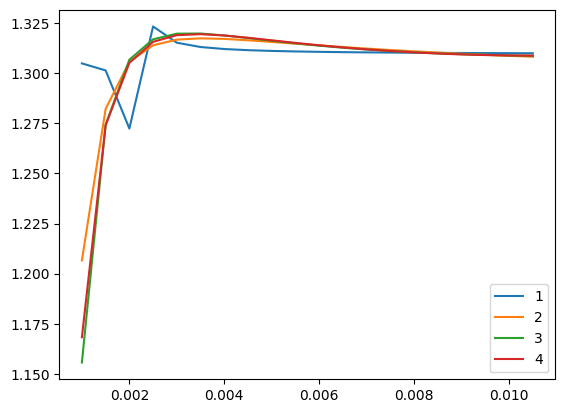

In [47]:
JW_fit = Polynomial.fit(depths, JW_mean_depths, deg=1)
TH_fit = Polynomial.fit(depths, TH_mean_depths, deg=1)
plt.plot(depths, JW_fit(depths)/TH_fit(depths), label='1')

JW_fit = Polynomial.fit(depths, JW_mean_depths, deg=2)
TH_fit = Polynomial.fit(depths, TH_mean_depths, deg=2)
plt.plot(depths, JW_fit(depths)/TH_fit(depths), label='2')

JW_fit = Polynomial.fit(depths, JW_mean_depths, deg=3)
TH_fit = Polynomial.fit(depths, TH_mean_depths, deg=3)
plt.plot(depths, JW_fit(depths)/TH_fit(depths), label='3')

JW_fit = Polynomial.fit(depths, JW_mean_depths, deg=4)
TH_fit = Polynomial.fit(depths, TH_mean_depths, deg=4)
plt.plot(depths, JW_fit(depths)/TH_fit(depths), label='4')

plt.legend()

plt.show()

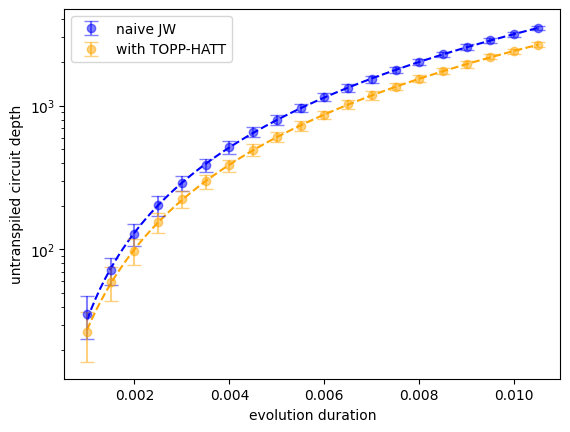

In [ ]:
naive_edge = 'blue'
naive_fill = 'cornflowerblue'
tophatt_edge = 'orange'
tophatt_fill = 'moccasin'

plt.tight_layout()

depths_fine = np.linspace(min(depths), max(depths), 100)

plt.plot(depths_fine, JW_fit(depths_fine), '--', color=naive_edge)
plt.plot(depths_fine, TH_fit(depths_fine), '--', color=tophatt_edge)

plt.errorbar(
    depths,
    JW_mean_depths,
    yerr=JW_std_depths,
    fmt='o',
    color=naive_edge,
    capsize=5,
    alpha=0.5,
    label='naive JW'
)

plt.errorbar(
    depths,
    TH_mean_depths,
    yerr=TH_std_depths,
    fmt='o',
    color=tophatt_edge,
    capsize=5,
    alpha=0.5,
    label='with TOPP-HATT' 
)

plt.xlabel('evolution duration')
plt.ylabel('untranspiled circuit depth')

plt.yscale('log')

plt.legend()

plt.savefig("qdrift_depths_scan.pdf")

plt.show()

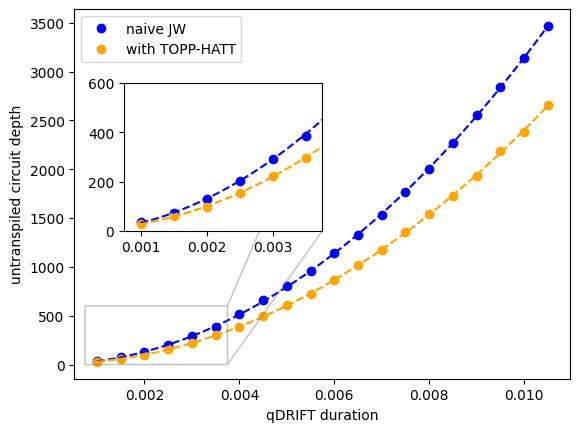

In [49]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots()

ax.plot(depths, JW_mean_depths, 'o', label='naive JW', color=naive_edge)
ax.plot(depths, TH_mean_depths, 'o', label='with TOPP-HATT', color=tophatt_edge)

depths_fine = np.linspace(min(depths), max(depths), 100)

ax.plot(depths_fine, JW_fit(depths_fine), '--', color=naive_edge)
ax.plot(depths_fine, TH_fit(depths_fine), '--', color=tophatt_edge)

ax.legend()

ax.set_xlabel('qDRIFT duration')
ax.set_ylabel('untranspiled circuit depth')

axin = ax.inset_axes([0.1, 0.4, 0.4, 0.4])

axin.plot(depths, JW_mean_depths, 'o', label='naive JW', color=naive_edge)
axin.plot(depths, TH_mean_depths, 'o', label='with TOPP-HATT', color=tophatt_edge)

axin.plot(depths_fine, JW_fit(depths_fine), '--', color=naive_edge)
axin.plot(depths_fine, TH_fit(depths_fine), '--', color=tophatt_edge)

axin.set_xlim(0.00075, 0.00375)
axin.set_ylim(0, 600)

ax.indicate_inset_zoom(axin)

plt.show()